# Task 1: Data Preparation and EDA
This notebook implements the first task of the music generation project using an LSTM Autoencoder. We will be using the Maestro dataset and preprocessing MIDI files into piano roll representations.

In [ ]:
!pip install pretty_midi music21

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.3 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=ed70f370dab75ef44c5415869510133405163a8594920fcd4fac6280ce54f8d4
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import librosa.display
import glob

# Mount Google Drive
drive.mount('/content/drive')

# Updated path based on your Drive contents
DATASET_PATH = '/content/drive/MyDrive/maestro-v3.0.0-midi'

# Recursive search for the CSV file
csv_files = glob.glob(os.path.join(DATASET_PATH, '**/*.csv'), recursive=True)

if csv_files:
    csv_path = csv_files[0]
    print(f'Loading metadata from: {csv_path}')
    df = pd.read_csv(csv_path)
    display(df.head())
else:
    print(f'Metadata CSV not found in {DATASET_PATH}. Please ensure the CSV file is inside this folder or its subfolders.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading metadata from: /content/drive/MyDrive/maestro-v3.0.0-midi/maestro-v3.0.0/maestro-v3.0.0.csv


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


## Step 2: Exploratory Data Analysis (EDA)
We will analyze the dataset to understand piece duration, note density, pitch/velocity distributions, and piano roll sparsity.

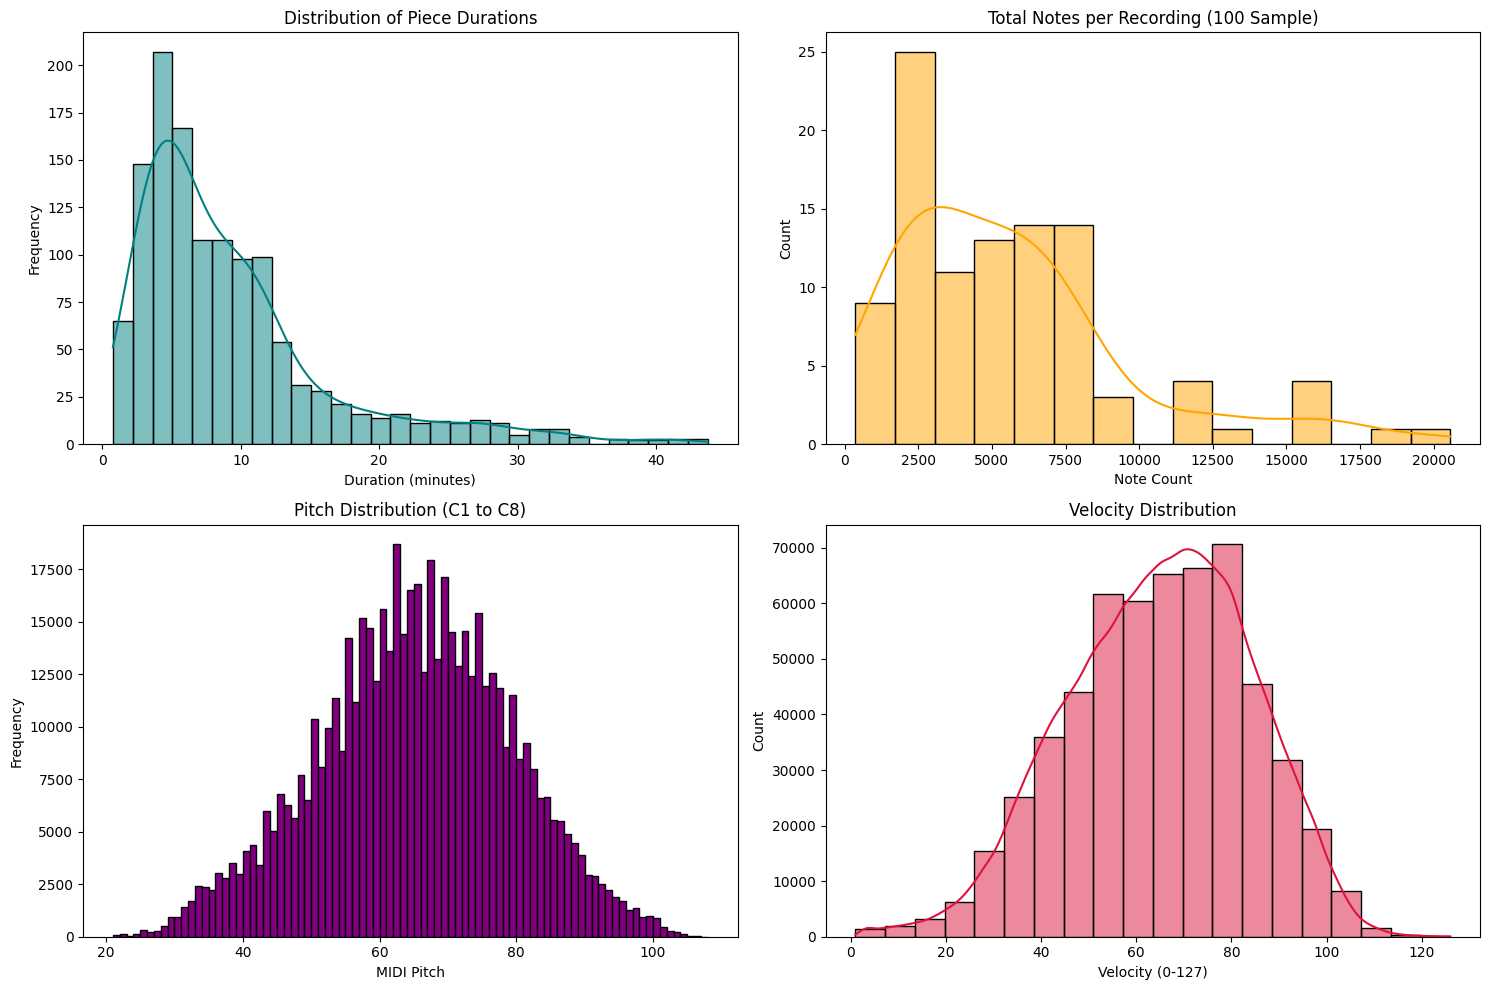

In [ ]:
import seaborn as sns

if 'df' in locals():
    plt.figure(figsize=(15, 10))

    # 1. Piece Duration Histogram
    plt.subplot(2, 2, 1)
    sns.histplot(df['duration'] / 60, bins=30, kde=True, color='teal')
    plt.title('Distribution of Piece Durations')
    plt.xlabel('Duration (minutes)')
    plt.ylabel('Frequency')

    # 2. Note Count Analysis (Using pretty_midi on a larger sample)
    base_dir = os.path.dirname(csv_path)
    sample_files = df.sample(100) # Increased to 100
    note_counts = []
    all_pitches = []
    all_velocities = []

    for _, row in sample_files.iterrows():
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(base_dir, row['midi_filename']))
            notes = [n for inst in pm.instruments if not inst.is_drum for n in inst.notes]
            note_counts.append(len(notes))
            all_pitches.extend([n.pitch for n in notes])
            all_velocities.extend([n.velocity for n in notes])
        except:
            continue

    plt.subplot(2, 2, 2)
    sns.histplot(note_counts, bins=15, kde=True, color='orange')
    plt.title('Total Notes per Recording (100 Sample)')
    plt.xlabel('Note Count')

    # 3. Pitch Distribution (88 Piano Pitches)
    plt.subplot(2, 2, 3)
    plt.hist(all_pitches, bins=np.arange(21, 109), color='purple', edgecolor='black')
    plt.title('Pitch Distribution (C1 to C8)')
    plt.xlabel('MIDI Pitch')
    plt.ylabel('Frequency')

    # 4. Velocity Distribution
    plt.subplot(2, 2, 4)
    sns.histplot(all_velocities, bins=20, kde=True, color='crimson')
    plt.title('Velocity Distribution')
    plt.xlabel('Velocity (0-127)')

    plt.tight_layout()
    plt.show()

In [ ]:
# Define the sample size for analysis
sample_size = 50
sample_files = df.sample(sample_size)

### Sparsity Check (Piano Roll Analysis)

We will analyze the sparsity of the piano roll representation. A high sparsity indicates that only a few notes are played at any given time, which is common in many musical pieces. This is important for understanding the input data characteristics for models like autoencoders.

In [ ]:
# Calculate Piano Roll Sparsity
# A piano roll is a binary matrix where rows are pitches and columns are time steps.
# A value of 1 indicates a note is playing, 0 indicates no note.

piano_roll_sparsity = []

for _, row in sample_files.iterrows():
    try:
        pm = pretty_midi.PrettyMIDI(os.path.join(base_dir, row['midi_filename']))
        # Get piano roll with 100ms resolution
        piano_roll = pm.get_piano_roll(fs=16)

        # Calculate sparsity: percentage of zero values
        total_elements = piano_roll.size
        zero_elements = np.count_nonzero(piano_roll == 0)
        sparsity = (zero_elements / total_elements) * 100
        piano_roll_sparsity.append(sparsity)
    except Exception as e:
        print(f"Could not process {row['midi_filename']}: {e}")
        continue

if piano_roll_sparsity:
    avg_sparsity = np.mean(piano_roll_sparsity)
    print(f"Average Piano Roll Sparsity (over {len(piano_roll_sparsity)} samples): {avg_sparsity:.2f}%")
else:
    print("No piano roll sparsity data could be generated.")

Average Piano Roll Sparsity (over 50 samples): 96.48%


## Step 3: LAKH Dataset EDA
We will now locate and analyze the LAKH dataset to compare its characteristics with the Maestro dataset.

In [ ]:
import glob
import os

# Broad search for any folder containing 'archiv' to find the LAKH dataset
search_paths = glob.glob('/content/drive/MyDrive/**/*archiv*', recursive=True)

if search_paths:
    print("Found matching paths:")
    for path in search_paths:
        if os.path.isdir(path):
            print(f"Directory: {path}")
            # List subdirectories to find lmd_full or similar
            subdirs = os.listdir(path)
            print(f"  Contents: {subdirs[:5]}...")

            if any('lmd' in s.lower() for s in subdirs):
                LAKH_DATASET_PATH = path
                print(f"*** Potential LAKH match found at: {LAKH_DATASET_PATH} ***")
else:
    print("No paths matching 'archiv' or 'archieve' found in Drive.")

Found matching paths:
Directory: /content/drive/MyDrive/archive
  Contents: ['.DS_Store', '.gitattributes', 'A_Teens', 'Al_Jarreau', 'A_Taste_of_Honey']...


Found 695 MIDI files. Analyzing 100 samples...


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


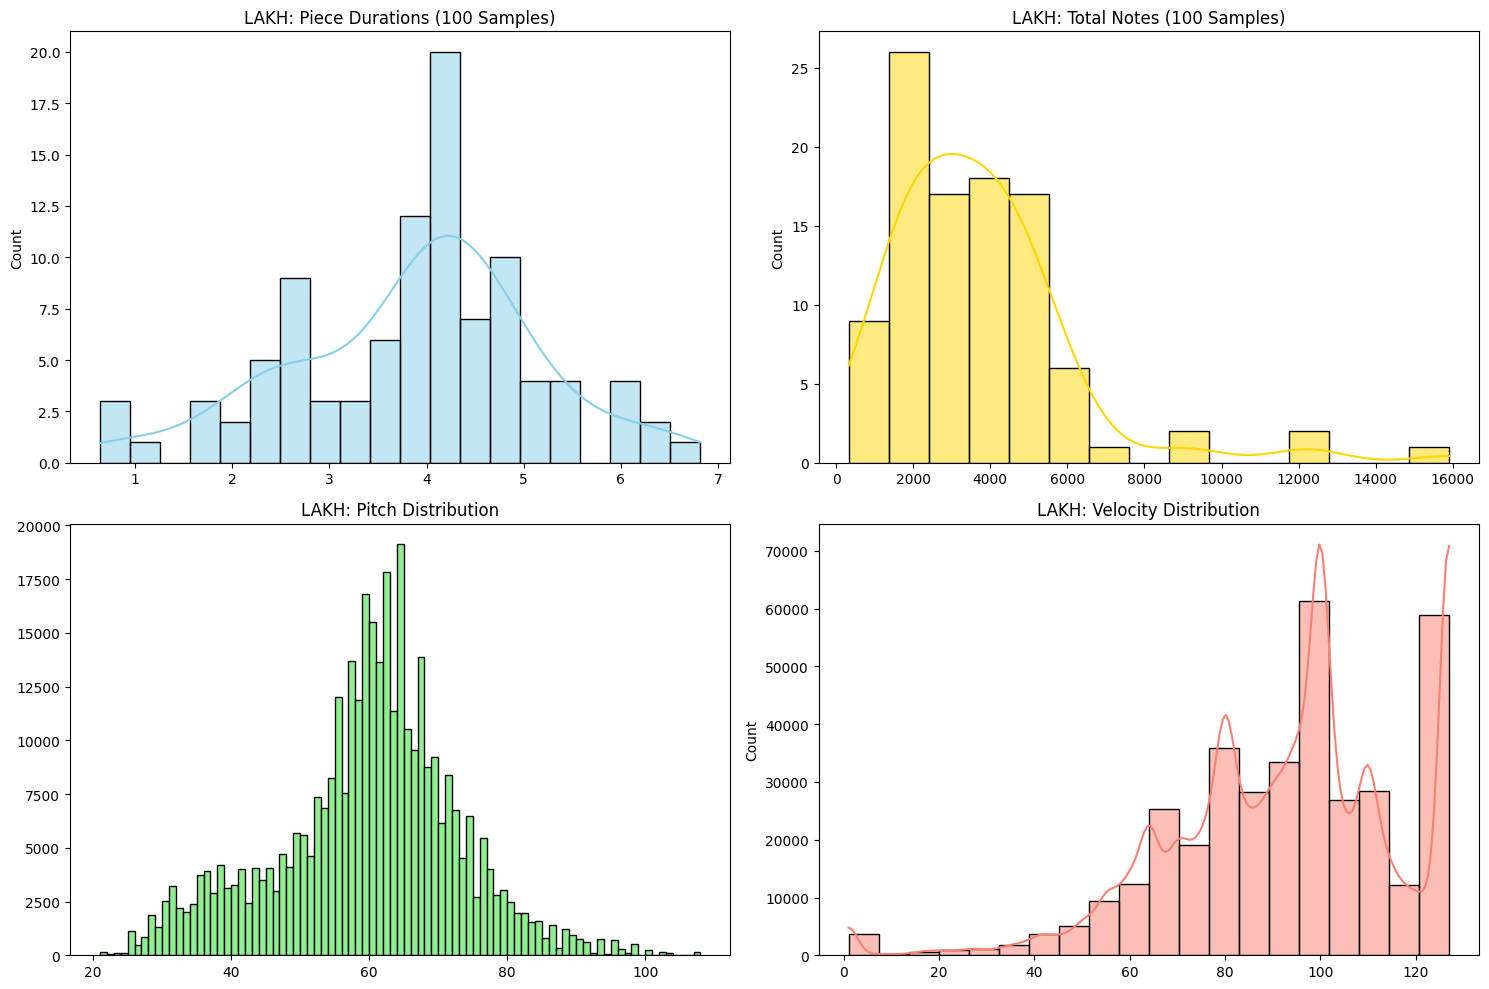

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import pretty_midi

def analyze_midi_sample(file_list, dataset_name, sample_size=100):
    note_counts = []
    all_pitches = []
    all_velocities = []
    durations = []

    # Increased sampling for better statistics
    for f in file_list[:sample_size]:
        try:
            pm = pretty_midi.PrettyMIDI(f)
            notes = [n for inst in pm.instruments if not inst.is_drum for n in inst.notes]
            if not notes:
                continue
            note_counts.append(len(notes))
            all_pitches.extend([n.pitch for n in notes])
            all_velocities.extend([n.velocity for n in notes])
            durations.append(pm.get_end_time())
        except Exception:
            continue

    return durations, note_counts, all_pitches, all_velocities

LAKH_PATH = '/content/drive/MyDrive/archive'
lakh_midis = glob.glob(os.path.join(LAKH_PATH, '**/*.mid*'), recursive=True)

if lakh_midis:
    print(f"Found {len(lakh_midis)} MIDI files. Analyzing 100 samples...")
    l_dur, l_notes, l_pitches, l_vel = analyze_midi_sample(lakh_midis, 'LAKH', 100)

    if l_dur:
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 2, 1)
        sns.histplot(np.array(l_dur)/60, bins=20, kde=True, color='skyblue')
        plt.title('LAKH: Piece Durations (100 Samples)')
        plt.subplot(2, 2, 2)
        sns.histplot(l_notes, bins=15, kde=True, color='gold')
        plt.title('LAKH: Total Notes (100 Samples)')
        plt.subplot(2, 2, 3)
        plt.hist(l_pitches, bins=np.arange(21, 109), color='lightgreen', edgecolor='black')
        plt.title('LAKH: Pitch Distribution')
        plt.subplot(2, 2, 4)
        sns.histplot(l_vel, bins=20, kde=True, color='salmon')
        plt.title('LAKH: Velocity Distribution')
        plt.tight_layout()
        plt.show()

## Step 4: Groove Dataset EDA
Locating and analyzing the Groove dataset from Google Drive.

Found 1150 MIDI files. Analyzing 100 samples (including drums)... 


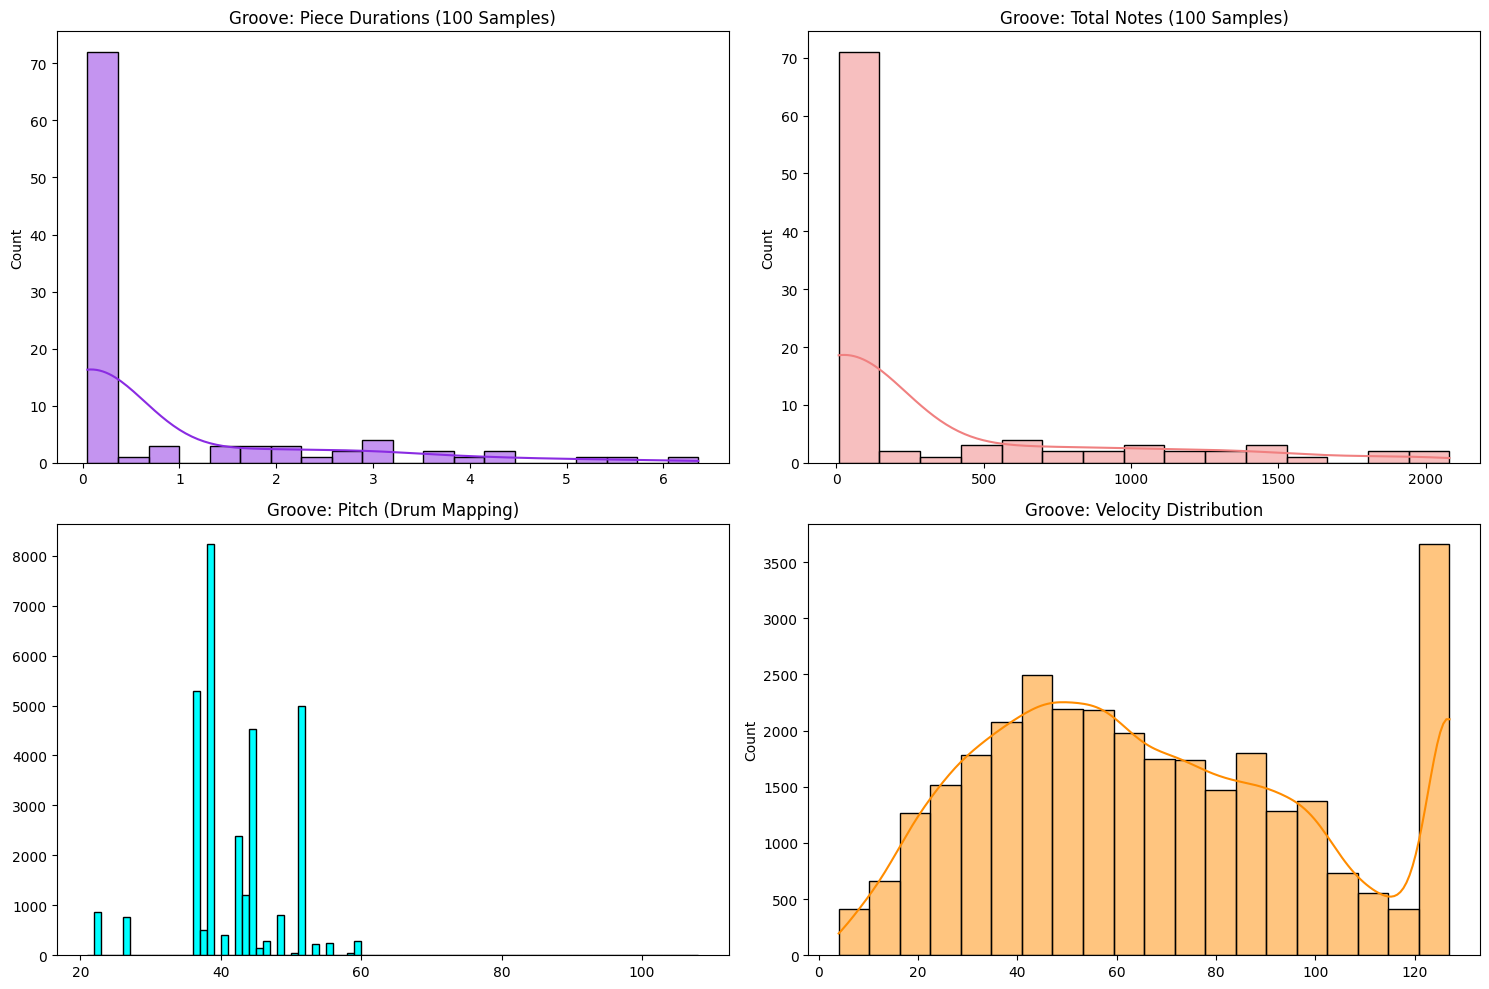

In [ ]:
def analyze_groove_sample(file_list, sample_size=100):
    note_counts = []
    all_pitches = []
    all_velocities = []
    durations = []

    for f in file_list[:sample_size]:
        try:
            pm = pretty_midi.PrettyMIDI(f)
            notes = [n for inst in pm.instruments for n in inst.notes]
            if not notes:
                continue
            note_counts.append(len(notes))
            all_pitches.extend([n.pitch for n in notes])
            all_velocities.extend([n.velocity for n in notes])
            durations.append(pm.get_end_time())
        except Exception:
            continue

    return durations, note_counts, all_pitches, all_velocities

if GROOVE_PATH:
    groove_midis = glob.glob(os.path.join(GROOVE_PATH, '**/*.mid*'), recursive=True)
    print(f"Found {len(groove_midis)} MIDI files. Analyzing 100 samples (including drums)... ")
    g_dur, g_notes, g_pitches, g_vel = analyze_groove_sample(groove_midis, 100)

    if g_dur:
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 2, 1)
        sns.histplot(np.array(g_dur)/60, bins=20, kde=True, color='blueviolet')
        plt.title('Groove: Piece Durations (100 Samples)')
        plt.subplot(2, 2, 2)
        sns.histplot(g_notes, bins=15, kde=True, color='lightcoral')
        plt.title('Groove: Total Notes (100 Samples)')
        plt.subplot(2, 2, 3)
        plt.hist(g_pitches, bins=np.arange(21, 109), color='cyan', edgecolor='black')
        plt.title('Groove: Pitch (Drum Mapping)')
        plt.subplot(2, 2, 4)
        sns.histplot(g_vel, bins=20, kde=True, color='darkorange')
        plt.title('Groove: Velocity Distribution')
        plt.tight_layout()
        plt.show()